In [72]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
from mne.filter import filter_data


### Config

In [73]:
CHANNEL_NAMES = [
    "FP1",
    "F3",
    "F7",
    "C3",
    "T3",
    "P3",
    "T5",
    "O1",
    "FP2",
    "F4",
    "F8",
    "C4",
    "T4",
    "P4",
    "T6",
    "O2"
]

In [74]:
ROOT = "../data/subjectV"
DATE = "20260617"
files = os.listdir(ROOT)

STAMPS = np.unique( [f.split("_")[-1][:-4] for f in files] )

STAMP_ID = 1

STAMP = STAMPS[STAMP_ID]

#### Load data

In [75]:
# Loading EEG
df_eeg = pd.read_csv(f"{ROOT}/V_eeg_{DATE}_{STAMP}.csv")
timestamps = df_eeg.lsl_timestamp.values
EEG = df_eeg.iloc[:, 1:-1].values
button = df_eeg.iloc[:, -1].values.astype(bool)

N, N_CHANNELS = EEG.shape

FS = 250. # Sampling frequency

## Go/No-Go Task (`scripts/gng_task.py`)

PyGame + LSL experiment for motor intention data collection.

**Run:**
```bash
python scripts/gng_task.py --out-dir data/gng --prefix S01
```

Outputs two CSVs per session: `<prefix>_markers_<datetime>.csv` and `<prefix>_eeg_<datetime>.csv`.

### LSL Marker Codes

| Code | Label | Meaning |
|------|-------|---------|
| 5 | `S1_warning` | S1 warning cue onset |
| 10 | `go_onset` | Go stimulus (S2) onset |
| 20 | `nogo_onset` | No-Go stimulus (S2) onset |
| 30 | `button_press` | Button press detected |
| 11 | `hit` | Go + pressed in time |
| 12 | `miss` | Go + no press |
| 21 | `correct_rejection` | No-Go + no press |
| 22 | `false_alarm` | No-Go + pressed |
| 99 | `end` | Experiment end |


In [76]:
# Loading markers
df_markers = pd.read_csv(f"{ROOT}/V_markers_{DATE}_{STAMP}.csv")

In [77]:
df_eeg.head()

,lsl_timestamp,ch0,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,ch9,ch10,ch11,ch12,ch13,ch14,ch15,ch16
0,471499.207819,66767.703125,-25437.000000,2218.459961,715907.1250,254955.781250,82812.937500,-46636.378906,-51254.339844,-81887.851562,2248.229980,-67902.812500,1126967.250,428056.43750,-68781.226562,3875.790039,-68042.007812,0.0
1,471499.211825,66673.820312,-25515.320312,2138.790039,715843.8125,254897.312500,82740.523438,-46732.128906,-51343.121094,-81635.718750,2119.479980,-67909.242188,1126706.000,427954.78125,-68670.460938,3872.040039,-67946.257812,0.0
2,471499.215830,66242.523438,-25340.439453,1777.229980,715487.8750,254603.609375,82473.640625,-47172.011719,-51568.691406,-81273.351562,1767.579956,-67998.828125,1126358.625,427717.12500,-68513.007812,3874.449951,-67841.648438,0.0
3,471499.219835,66025.796875,-25111.650391,1613.890015,715356.4375,254501.953125,82361.523438,-47348.769531,-51618.039062,-81285.687500,1681.479980,-68028.601562,1126396.375,427660.56250,-68505.773438,3890.010010,-67868.476562,0.0
4,471499.223840,66265.859375,-25153.759766,1835.439941,715646.9375,254739.328125,82528.093750,-47037.371094,-51435.378906,-81629.007812,1986.439941,-67945.187500,1126755.875,427877.81250,-68640.953125,3910.659912,-67971.468750,0.0


In [78]:
df_markers.head()

,lsl_timestamp,marker_code,marker_label,trial_type
0,471499.207819,10,go_onset,go
1,471499.682528,30,button_press,go
2,471499.682544,11,hit,go
3,471501.194358,20,nogo_onset,nogo
4,471503.195728,21,correct_rejection,nogo


### Preprocess EEG

In [79]:
EEG = filter_data(EEG.T[None], 250, .5, 28., verbose=False).squeeze()

In [80]:
EEG.shape

(16, 67584)

In [81]:
# Apply CAR

EEG -= EEG.mean(axis=0, keepdims=True)

### Check evoked potentials

In [82]:
WINDOW = 2.
N_SAMPLES = int(WINDOW * FS) + 1  # fixed epoch length
T_ARRAY = np.arange(0, WINDOW + 1 / FS, 1 / FS)

In [83]:
go_onsets = df_markers.loc[df_markers.marker_code == 10].lsl_timestamp.values

GO_ERP = []

for onset in go_onsets:
    idx_start = np.searchsorted(timestamps, onset)
    GO_ERP.append(EEG[:, idx_start : idx_start + N_SAMPLES])

GO_ERP = np.stack(GO_ERP)


In [84]:
nogo_onsets = df_markers.loc[df_markers.marker_code == 20].lsl_timestamp.values

NOGO_ERP = []

for onset in nogo_onsets:
    idx_start = np.searchsorted(timestamps, onset)
    NOGO_ERP.append(EEG[:, idx_start : idx_start + N_SAMPLES])

NOGO_ERP = np.stack(NOGO_ERP)

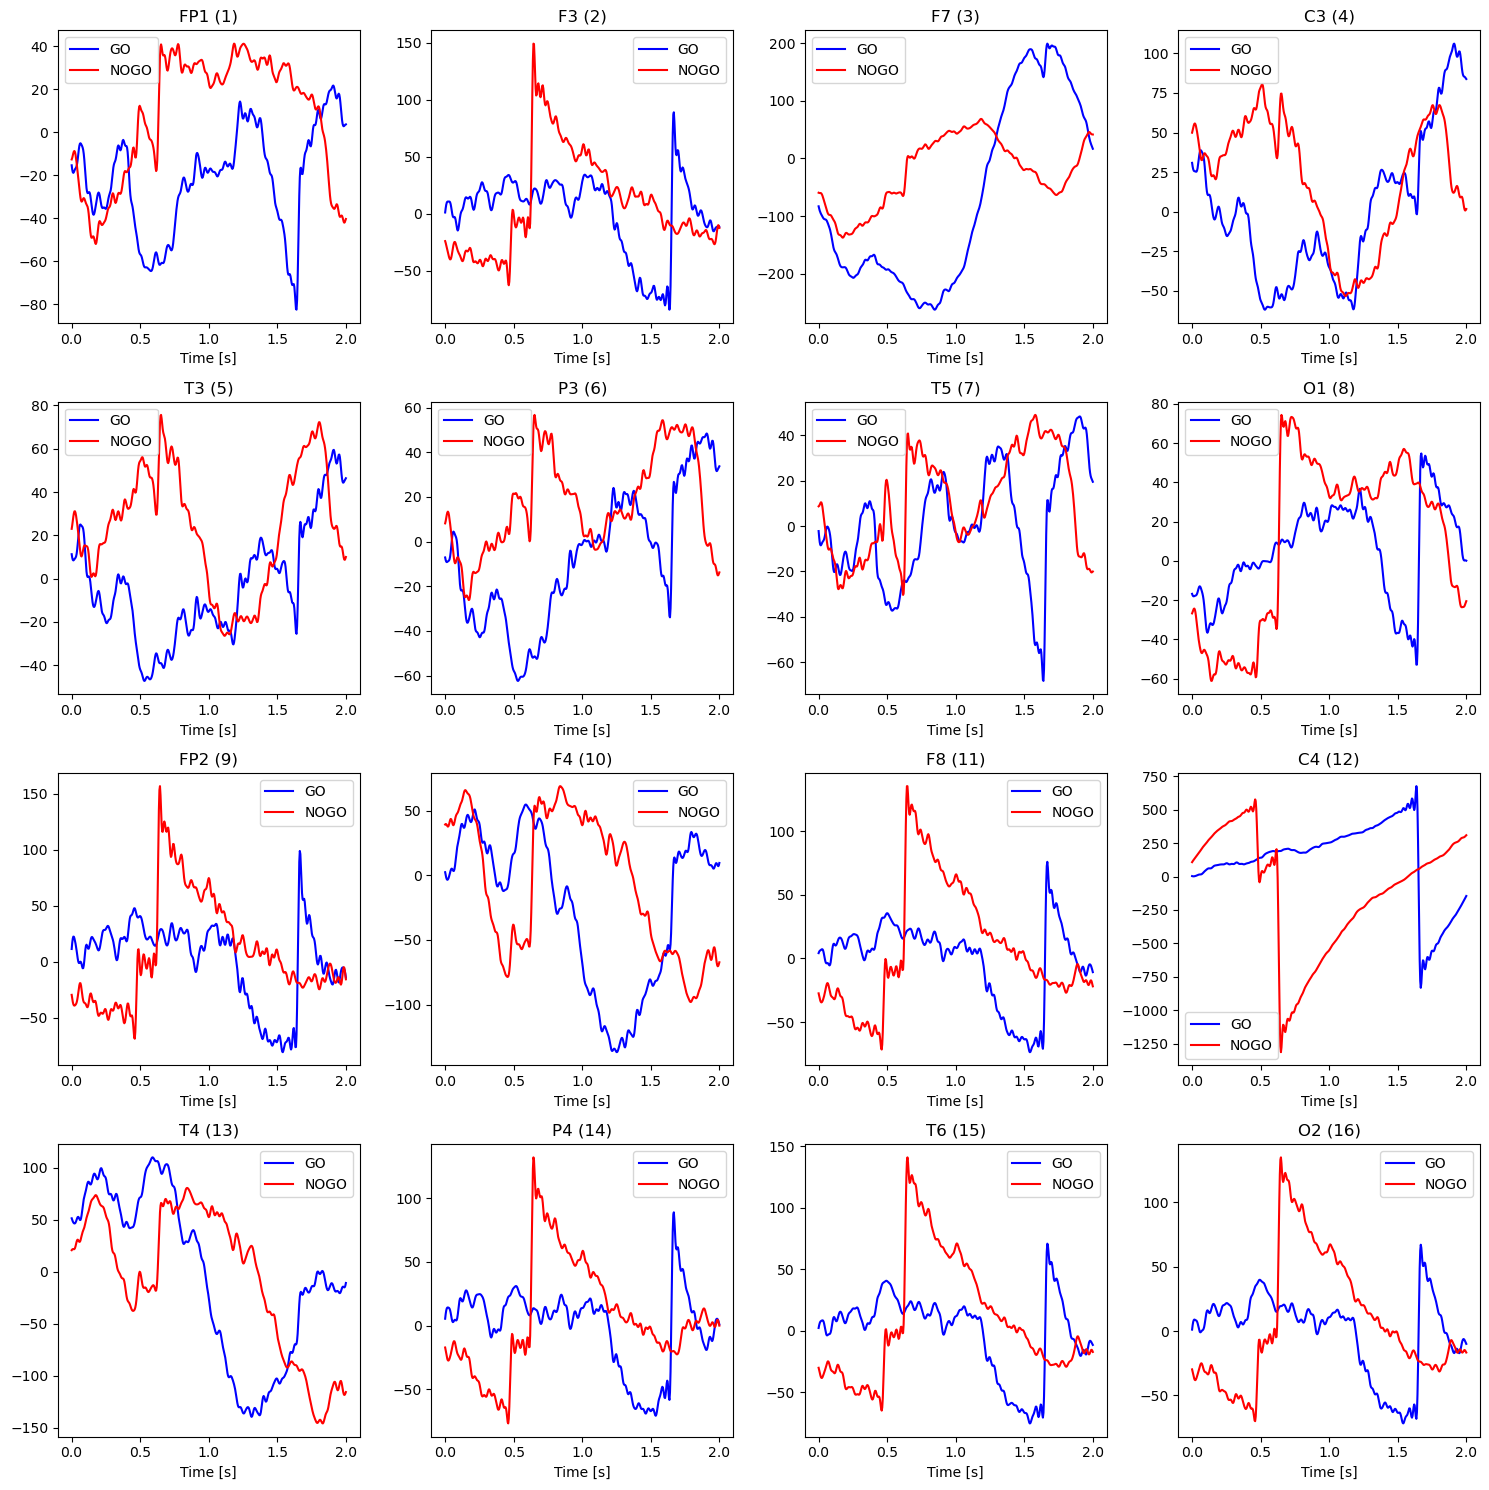

In [85]:
plt.figure(figsize=(15, 15))
for pos in range(N_CHANNELS):
    plt.subplot(4, 4, pos + 1)
    plt.plot( T_ARRAY, GO_ERP.mean(0)[pos], "b" , label="GO") 
    plt.plot( T_ARRAY, NOGO_ERP.mean(0)[pos], "r"  , label="NOGO") 
    plt.title(f"{CHANNEL_NAMES[pos]} ({pos + 1})")
    plt.xlabel("Time [s]")
    plt.legend()
plt.tight_layout()

In [86]:
NOGO_MEAN = NOGO_ERP.mean(axis=0)            # (16, 376)
GO_ERP_corrected = GO_ERP.mean(axis=0) - NOGO_MEAN  # (16, 376)

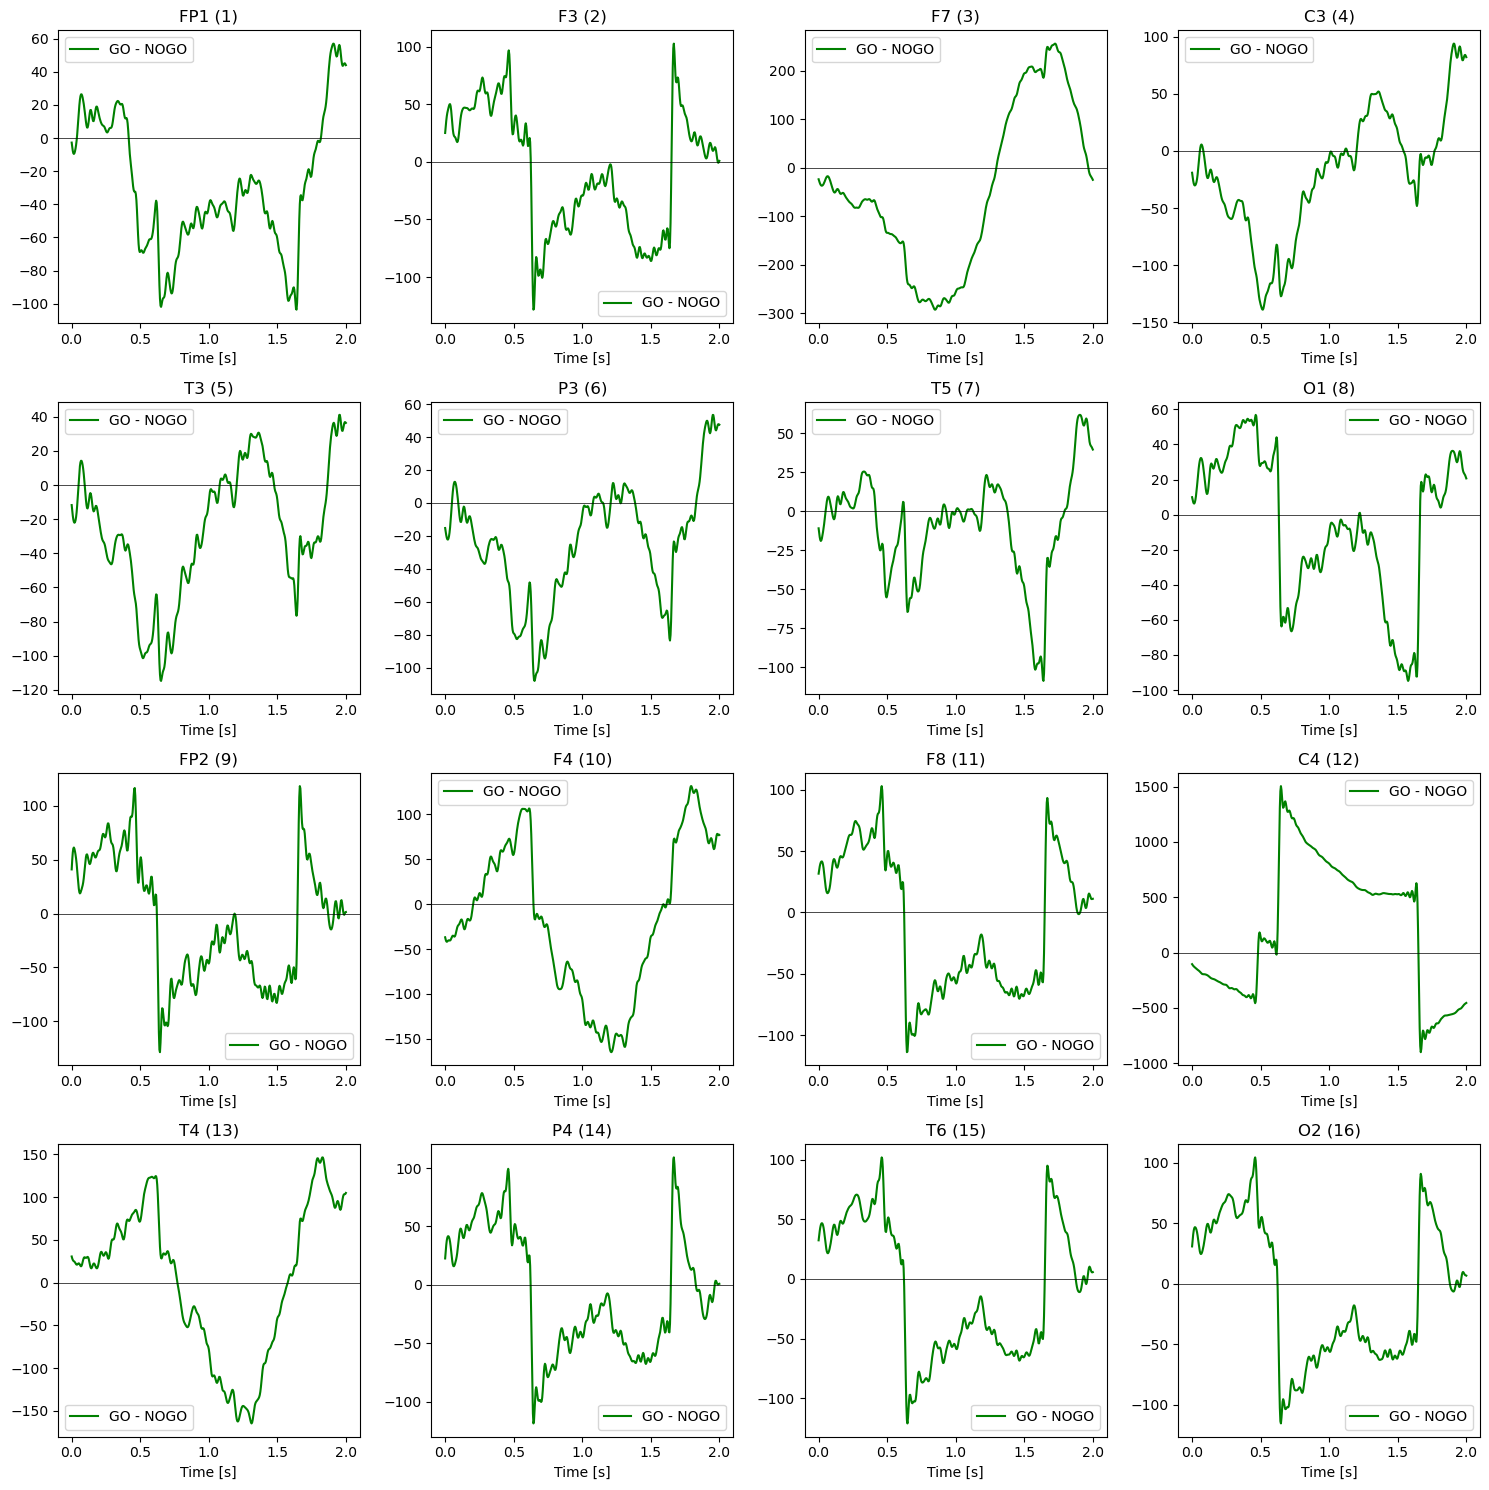

In [87]:
plt.figure(figsize=(15, 15))
for pos in range(N_CHANNELS):
    plt.subplot(4, 4, pos + 1)
    plt.plot(T_ARRAY, GO_ERP_corrected[pos], "g", label="GO - NOGO")
    plt.axhline(0, color="k", linewidth=0.5)
    plt.title(f"{CHANNEL_NAMES[pos]} ({pos + 1})")
    plt.xlabel("Time [s]")
    plt.legend()
plt.tight_layout()

In [88]:
TEMPLATES = scipy.stats.zscore(GO_ERP_corrected, axis=1)

In [89]:
wi, wf = 0, N_SAMPLES

CC = []
TIMES = []
while wf < N:

    SNIPET = scipy.stats.zscore(EEG[:, wi:wf], axis=1)

    CC.append( (SNIPET * TEMPLATES).mean(1) )
    TIMES.append(timestamps[wi:wf].mean())
    
    wi += 1
    wf += 1
CC = np.stack(CC)

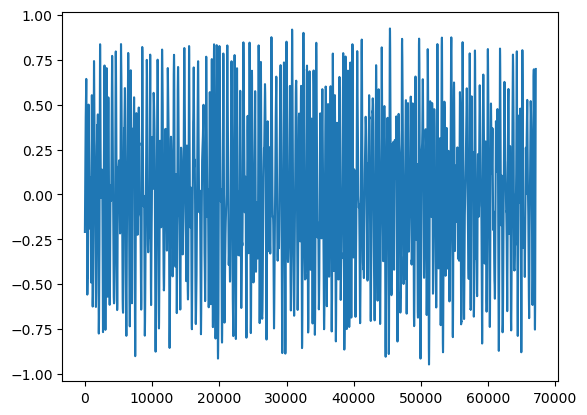

In [90]:
plt.plot(CC[:, 9])

In [91]:
DELTA = .5
N_SAMPLES = int(DELTA * FS) + 1  # fixed epoch length
T_ARRAY = np.arange(-DELTA - 1 / FS, DELTA + 2*1 / FS, 1 / FS)

In [93]:
HITS = df_markers.loc[df_markers.marker_label == "hit"].lsl_timestamp.values
CC_TA = [] # CC triggered average

for n in range(N_CHANNELS):

    X = CC[:, n]
    SNIPETS = []

    for hit in HITS:
        idx_start = np.searchsorted(timestamps, hit)
        i0 = idx_start - N_SAMPLES
        i1 = idx_start + N_SAMPLES + 1
        if i0 >= 0 and i1 <= len(X):
            SNIPETS.append(X[i0:i1])

    CC_TA.append( np.stack(SNIPETS).mean(axis=0) )


/var/folders/y4/188v_l8n7zzcs8c734ytzc3c0000gn/T/ipykernel_60341/4209840617.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


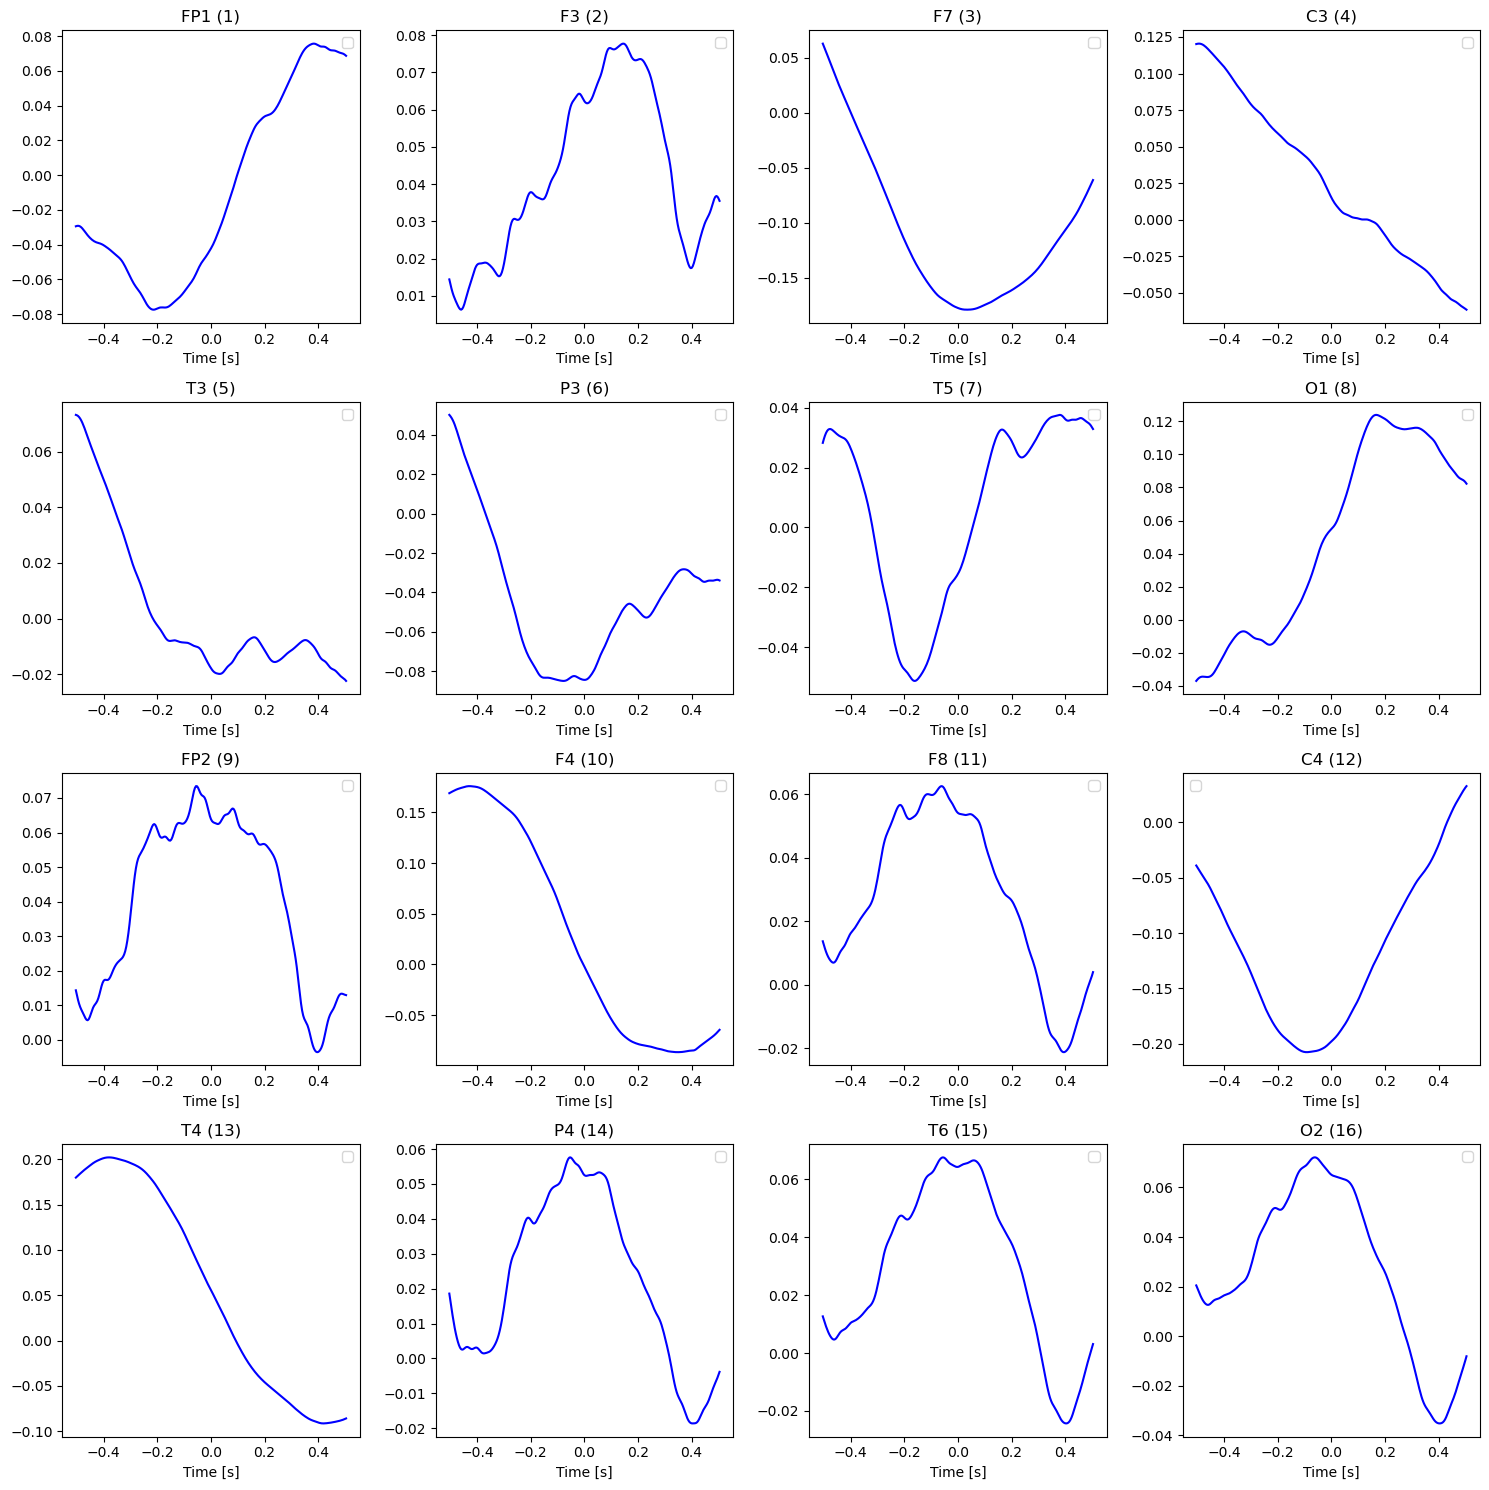

In [94]:
plt.figure(figsize=(15, 15))
for pos in range(N_CHANNELS):
    plt.subplot(4, 4, pos + 1)
    plt.plot( T_ARRAY, CC_TA[pos], "b") 
    plt.title(f"{CHANNEL_NAMES[pos]} ({pos + 1})")
    plt.xlabel("Time [s]")
    plt.legend()
plt.tight_layout()

In [95]:
from mne.decoding import CSP

In [105]:
CSP?

Init signature:
CSP(
    n_components=4,
    reg=None,
    log=None,
    cov_est='concat',
    transform_into='average_power',
    norm_trace=False,
    cov_method_params=None,
    rank=None,
    component_order='mutual_info',
)
Docstring:     
M/EEG signal decomposition using the Common Spatial Patterns (CSP).

This class can be used as a supervised decomposition to estimate spatial
filters for feature extraction. CSP in the context of EEG was first
described in :footcite:`KolesEtAl1990`; a comprehensive tutorial on CSP can
be found in :footcite:`BlankertzEtAl2008`. Multi-class solving is
implemented from :footcite:`Grosse-WentrupBuss2008`.

Parameters
----------
n_components : int (default 4)
    The number of components to decompose M/EEG signals. This number should
    be set by cross-validation.
reg : float | str | None (default None)
    If not None (same as ``'empirical'``, default), allow regularization
    for covariance estimation. If float (between 0 and 1), shrinkage is
   

In [116]:
csp = CSP()

In [117]:
csp.fit(np.concatenate((GO_ERP, NOGO_ERP)), [1] * 50 + [0] * 50) 

Computing rank from data with rank=None
    Using tolerance 2.2e+03 (2.2e-16 eps * 16 dim * 6.3e+17  max singular value)
    Estimated rank (data): 15
    data: rank 15 computed from 16 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 16 -> 15
Estimating class=0 covariance using EMPIRICAL
Done.
Estimating class=1 covariance using EMPIRICAL
Done.


,n_components,4
,reg,None
,log,None
,cov_est,'concat'
,transform_into,'average_power'
,norm_trace,False
,cov_method_params,None
,rank,None
,component_order,'mutual_info'


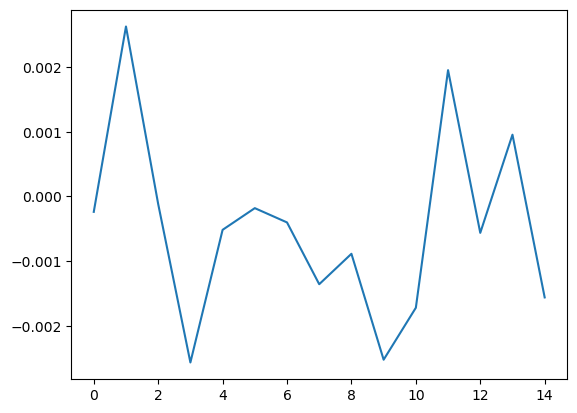

In [113]:
plt.plot( csp.filters_[:, 0] )

In [109]:
NOGO_ERP.shape

(50, 16, 501)

In [118]:
csp.patterns_.shape

(15, 16)

In [119]:
csp.filters_.shape


(15, 16)

In [120]:
X = np.concatenate([GO_ERP, NOGO_ERP])
y = np.r_[np.ones(50), np.zeros(50)]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [121]:
from mne.decoding import CSP
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

clf = Pipeline([
    ('csp', CSP(n_components=4)),
    ('lda', LinearDiscriminantAnalysis())
])

clf.fit(X_train, y_train)

Computing rank from data with rank=None
    Using tolerance 2.2e+03 (2.2e-16 eps * 16 dim * 6.2e+17  max singular value)
    Estimated rank (data): 15
    data: rank 15 computed from 16 data channels with 0 projectors
    Setting small data eigenvalues to zero (without PCA)
Reducing data rank from 16 -> 15
Estimating class=0.0 covariance using EMPIRICAL
Done.
Estimating class=1.0 covariance using EMPIRICAL
Done.


,steps,"[('csp', ...), ('lda', ...)]"
,transform_input,None
,memory,None
,verbose,False
,n_components,4
,reg,None
,log,None
,cov_est,'concat'
,transform_into,'average_power'
,norm_trace,False
,cov_method_params,None


In [122]:
acc = clf.score(X_test, y_test)

In [123]:
acc

0.55